In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow Version:", tf.__version__)
print("Student Roll No: 24BAD046")

TensorFlow Version: 2.20.0
Student Roll No: 24BAD046


In [2]:
# EXPT NO: 6
# IMPLEMENTATION OF LSTM FOR SENTIMENT ANALYSIS
# Student Roll No: 24BAD046

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow Version:", tf.__version__)
print("Student Roll No: 24BAD046")

# Parameters
VOCAB_SIZE = 10000
MAX_LENGTH = 200

# Load IMDB dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nFirst review as numerical sequence:")
print(X_train[0][:20])

print("\nFirst review sentiment:")
print("Positive" if y_train[0] == 1 else "Negative")

# Check class distribution
print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

# Padding sequences
X_train = pad_sequences(
    X_train,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_LENGTH,
    padding='post',
    truncating='post'
)

print("\nShape after padding:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nLabel shape:")
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

TensorFlow Version: 2.20.0
Student Roll No: 24BAD046
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: 25000
Testing samples: 25000

First review as numerical sequence:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]

First review sentiment:
Positive

Training class distribution:
1    12500
0    12500
Name: count, dtype: int64

Shape after padding:
X_train: (25000, 200)
X_test : (25000, 200)

Label shape:
y_train: (25000,)
y_test : (25000,)


In [3]:
# PART B: EMBEDDING GENERATION

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding

EMBEDDING_DIM = 128

# Create Embedding layer
embedding_layer = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_LENGTH
)

# Generate embedding representation for sample reviews
sample_data = X_train[:5]

embedded_output = embedding_layer(sample_data)

print("Input sequence shape:")
print(sample_data.shape)

print("\nEmbedding output shape:")
print(embedded_output.shape)

print("\nEmbedding dimension:", EMBEDDING_DIM)
print("Vocabulary size:", VOCAB_SIZE)

Input sequence shape:
(5, 200)

Embedding output shape:
(5, 200, 128)

Embedding dimension: 128
Vocabulary size: 10000


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [4]:
# PART C: IMPLEMENTING THE LSTM MODEL

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Create LSTM model
model = Sequential([

    # Embedding layer
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    # LSTM layer
    LSTM(64),

    # Dropout to reduce overfitting
    Dropout(0.5),

    # Output layer
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# PART D: MODEL TRAINING

EPOCHS = 5
BATCH_SIZE = 128

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 269ms/step - accuracy: 0.5178 - loss: 0.6923 - val_accuracy: 0.5046 - val_loss: 0.6946
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 333ms/step - accuracy: 0.6132 - loss: 0.6551 - val_accuracy: 0.7584 - val_loss: 0.5932
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 77s 298ms/step - accuracy: 0.6689 - loss: 0.6226 - val_accuracy: 0.7264 - val_loss: 0.5846
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 280ms/step - accuracy: 0.8037 - loss: 0.4894 - val_accuracy: 0.8000 - val_loss: 0.4944
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 44s 281ms/step - accuracy: 0.8262 - loss: 0.4530 - val_accuracy: 0.8006 - val_loss: 0.4936


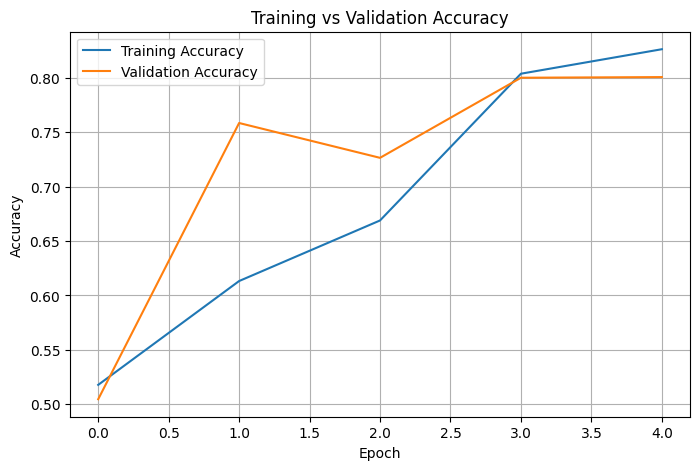

In [6]:
# Training and Validation Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

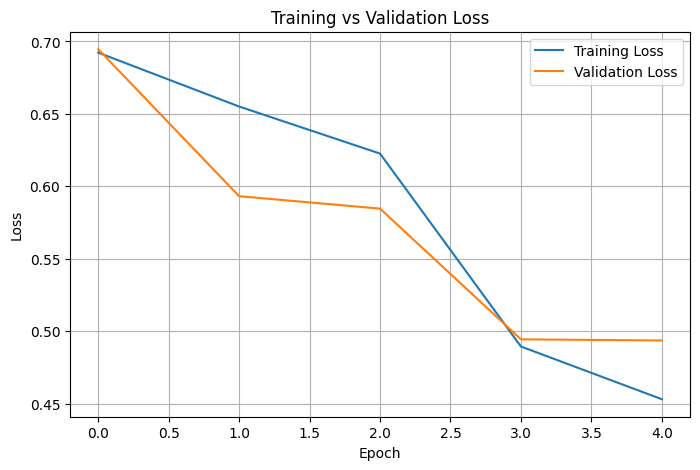

In [7]:
# Training and Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [8]:
# Evaluate model on test dataset

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Loss     :", test_loss)
print("Test Accuracy :", test_accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7927 - loss: 0.5038

Test Loss     : 0.5038220882415771
Test Accuracy : 0.792680025100708


In [9]:
# Generate predictions

y_probability = model.predict(X_test)

# Convert probability to binary class
y_pred = (y_probability >= 0.5).astype(int).flatten()

print("Predictions generated successfully.")

print("\nFirst 10 predicted values:")
print(y_pred[:10])

print("\nFirst 10 actual values:")
print(y_test[:10])

782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step
Predictions generated successfully.

First 10 predicted values:
[0 1 1 0 1 0 0 0 1 1]

First 10 actual values:
[0 1 1 0 1 1 1 0 0 1]


In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print("-----------------")

print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1-Score  :", round(f1, 4))

MODEL PERFORMANCE
-----------------
Accuracy  : 0.7927
Precision : 0.7717
Recall    : 0.8314
F1-Score  : 0.8004


Confusion Matrix:
[[ 9425  3075]
 [ 2108 10392]]


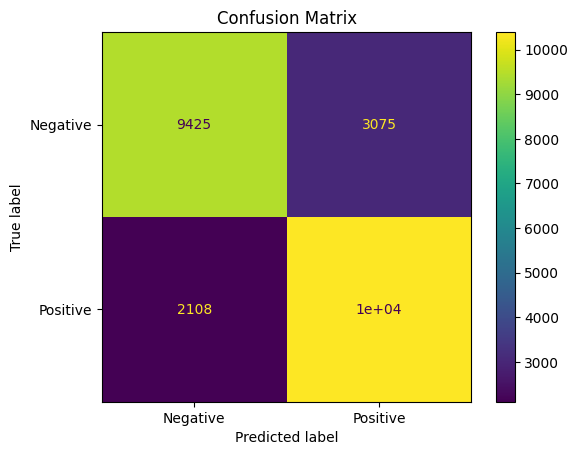

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive']
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [12]:
# Create word index
word_index = imdb.get_word_index()

# Function to convert text into IMDB numerical sequence
def encode_review(text):

    words = text.lower().split()

    sequence = []

    for word in words:
        index = word_index.get(word)

        # IMDB reserves indexes 0-3
        if index is not None:
            index = index + 3

            if index < VOCAB_SIZE:
                sequence.append(index)
            else:
                sequence.append(2)
        else:
            sequence.append(2)

    return sequence


# Function to predict sentiment
def predict_sentiment(text):

    sequence = encode_review(text)

    padded_sequence = pad_sequences(
        [sequence],
        maxlen=MAX_LENGTH,
        padding='post',
        truncating='post'
    )

    probability = model.predict(
        padded_sequence,
        verbose=0
    )[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("\nReview:", text)
    print("Sentiment:", sentiment)
    print("Probability:", round(float(probability), 4))


# Test reviews
predict_sentiment(
    "This movie was excellent and I really enjoyed watching it"
)

predict_sentiment(
    "This movie was terrible and very boring"
)

predict_sentiment(
    "The story was amazing and the actors performed very well"
)

predict_sentiment(
    "I hated this movie because it was boring and disappointing"
)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Review: This movie was excellent and I really enjoyed watching it
Sentiment: Positive
Probability: 0.8724

Review: This movie was terrible and very boring
Sentiment: Negative
Probability: 0.1733

Review: The story was amazing and the actors performed very well
Sentiment: Positive
Probability: 0.8724

Review: I hated this movie because it was boring and disappointing
Sentiment: Negative
Probability: 0.1733


In [13]:
# Final Results Summary

print("=" * 45)
print("       LSTM SENTIMENT ANALYSIS")
print("=" * 45)

print("Student Roll No :", "24BAD046")
print("Dataset         :", "IMDB Movie Reviews")
print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))
print("Vocabulary Size :", VOCAB_SIZE)
print("Sequence Length :", MAX_LENGTH)
print("Embedding Size  :", EMBEDDING_DIM)
print("LSTM Units      :", 64)
print("Epochs          :", EPOCHS)

print("\nPerformance")
print("-----------------------------")
print("Test Accuracy   :", round(accuracy, 4))
print("Precision       :", round(precision, 4))
print("Recall          :", round(recall, 4))
print("F1-Score        :", round(f1, 4))

print("\nExperiment completed successfully.")

       LSTM SENTIMENT ANALYSIS
Student Roll No : 24BAD046
Dataset         : IMDB Movie Reviews
Training Samples: 25000
Testing Samples : 25000
Vocabulary Size : 10000
Sequence Length : 200
Embedding Size  : 128
LSTM Units      : 64
Epochs          : 5

Performance
-----------------------------
Test Accuracy   : 0.7927
Precision       : 0.7717
Recall          : 0.8314
F1-Score        : 0.8004

Experiment completed successfully.
